In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def convolve_3x3_fast(image, kernel):
    """A fast from-scratch 2D convolution without using any built-in cv2 filters."""
    # Pad the image to handle borders
    padded = np.pad(image, 1, mode='edge').astype(np.float32)
    result = np.zeros_like(image, dtype=np.float32)
    
    # Slide the 3x3 kernel over the image using vectorized NumPy addition
    for i in range(3):
        for j in range(3):
            result += padded[i:i+image.shape[0], j:j+image.shape[1]] * kernel[i, j]
            
    return result

In [3]:
def compute_first_order_derivatives(img):
    # Sobel kernels
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)
                   
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float32)
    
    # 1. Compute Gx and Gy
    Gx = convolve_3x3_fast(img, Kx)
    Gy = convolve_3x3_fast(img, Ky)
    
    # 2. Compute Magnitude
    magnitude = np.sqrt(Gx**2 + Gy**2)
    # Normalize magnitude to 0-255 for display
    magnitude_disp = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # 3. Compute Direction (in degrees)
    direction = np.arctan2(Gy, Gx) * (180 / np.pi)
    
    return Gx, Gy, magnitude_disp, direction

In [5]:
img_boundaries = cv2.imread('./collectible-coins.jpg', cv2.IMREAD_GRAYSCALE)  # Clear boundaries
img_details = cv2.imread('./marilyn.jpeg', cv2.IMREAD_GRAYSCALE)   # Fine details

# Resize for consistency
img_boundaries = cv2.resize(img_boundaries, (512, 512))
img_details = cv2.resize(img_details, (512, 512))

# Compute for the boundaries image
Gx_b, Gy_b, mag_b, dir_b = compute_first_order_derivatives(img_boundaries)

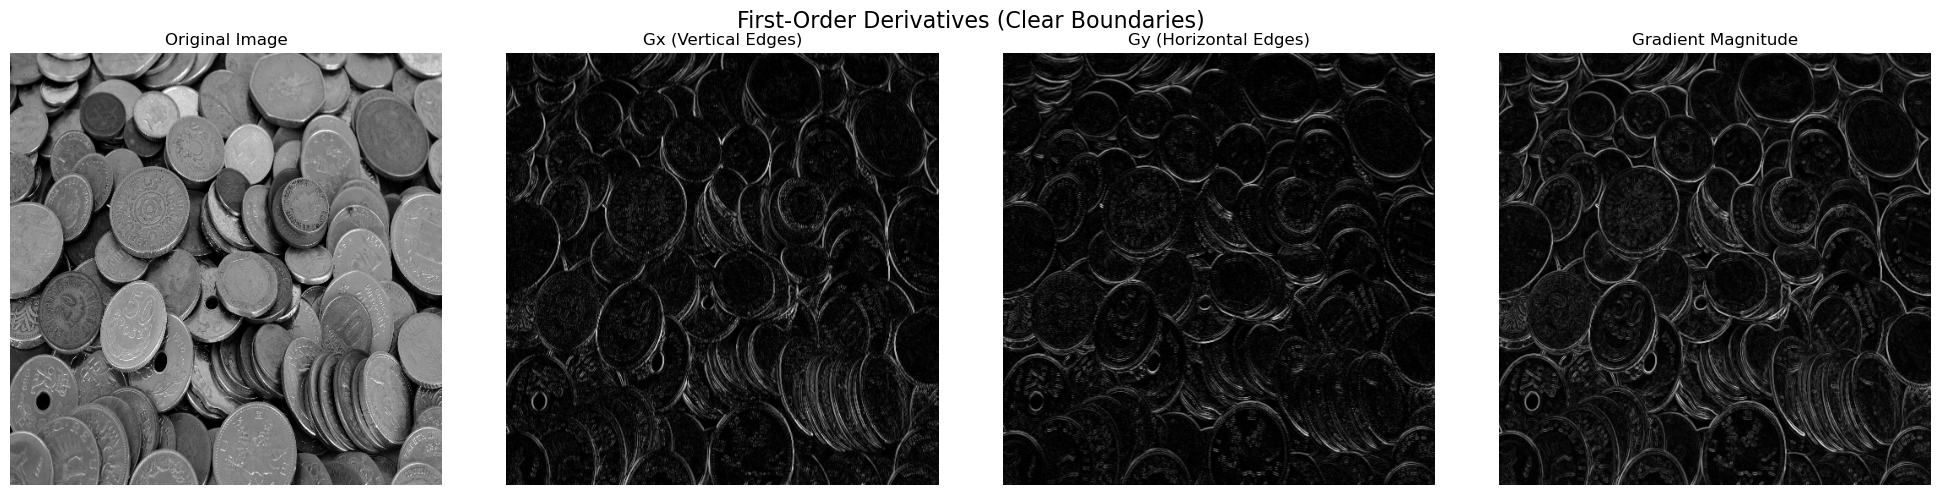

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("First-Order Derivatives (Clear Boundaries)", fontsize=16)

axes[0].imshow(img_boundaries, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Display Gx and Gy using 'gray' but normalized, or simply absolute values
axes[1].imshow(np.abs(Gx_b), cmap='gray')
axes[1].set_title("Gx (Vertical Edges)")
axes[1].axis('off')

axes[2].imshow(np.abs(Gy_b), cmap='gray')
axes[2].set_title("Gy (Horizontal Edges)")
axes[2].axis('off')

axes[3].imshow(mag_b, cmap='gray')
axes[3].set_title("Gradient Magnitude")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [8]:
def apply_threshold(magnitude_img, threshold):
    """Converts a gradient magnitude image to a binary edge map."""
    # Create an array of zeros (all black)
    binary_map = np.zeros_like(magnitude_img, dtype=np.uint8)
    
    # Where magnitude is greater than the threshold, set to 255 (white)
    binary_map[magnitude_img >= threshold] = 255
    
    return binary_map

In [9]:
# Define three different threshold values
T_LOW = 30
T_MEDIUM = 80
T_HIGH = 150

# Generate binary edge maps
edge_low = apply_threshold(mag_b, T_LOW)
edge_med = apply_threshold(mag_b, T_MEDIUM)
edge_high = apply_threshold(mag_b, T_HIGH)

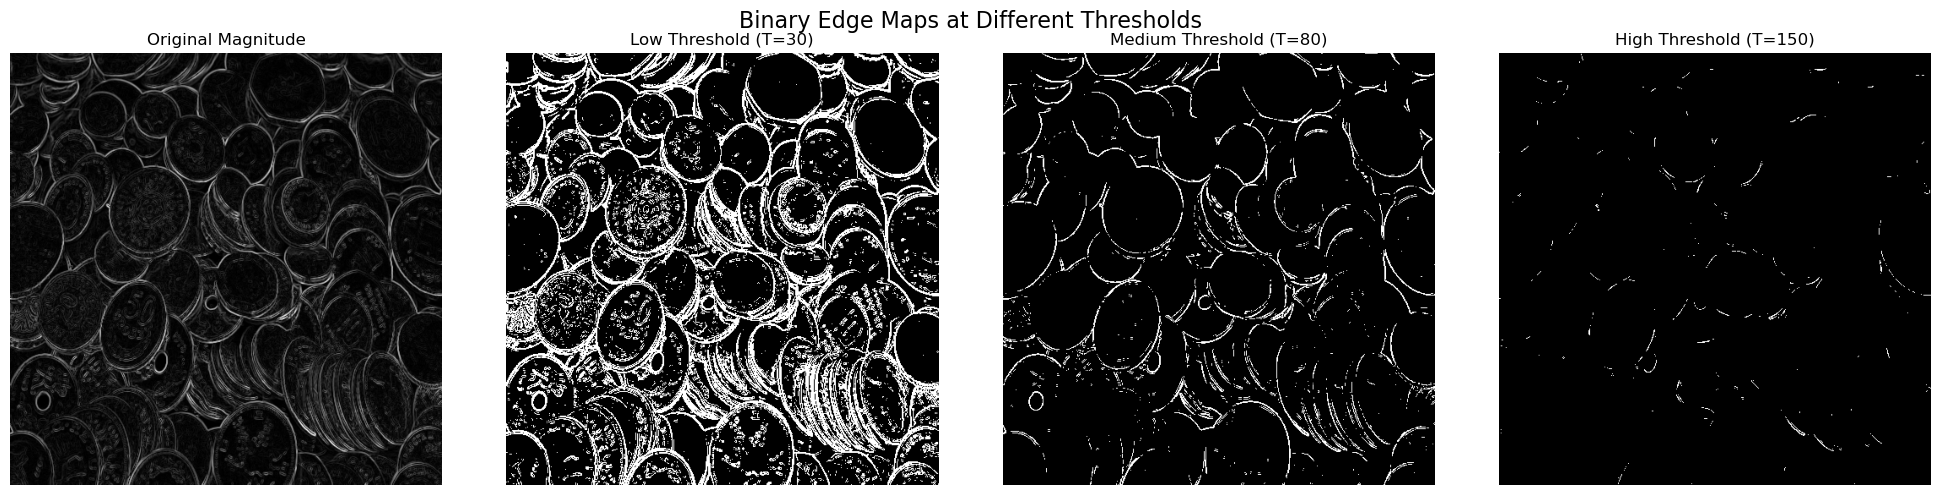

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Binary Edge Maps at Different Thresholds", fontsize=16)

axes[0].imshow(mag_b, cmap='gray')
axes[0].set_title("Original Magnitude")
axes[0].axis('off')

axes[1].imshow(edge_low, cmap='gray')
axes[1].set_title(f"Low Threshold (T={T_LOW})")
axes[1].axis('off')

axes[2].imshow(edge_med, cmap='gray')
axes[2].set_title(f"Medium Threshold (T={T_MEDIUM})")
axes[2].axis('off')

axes[3].imshow(edge_high, cmap='gray')
axes[3].set_title(f"High Threshold (T={T_HIGH})")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [11]:
def compute_laplacian_scratch(img):
    """Computes the Laplacian from scratch using an 8-neighbor kernel."""
    # Define the discrete Laplacian kernel
    K_lap = np.array([[ 1,  1,  1],
                      [ 1, -8,  1],
                      [ 1,  1,  1]], dtype=np.float32)
    
    # Apply our from-scratch convolution
    laplacian_raw = convolve_3x3_fast(img, K_lap)
    
    return laplacian_raw

In [12]:
lap_raw = compute_laplacian_scratch(img_boundaries)

# 2. Take absolute value (edges have both positive and negative spikes)
lap_abs = np.abs(lap_raw)

# 3. Create a binary edge map from the Laplacian
# We use a lower threshold here (e.g., 40) because the second derivative spreads the energy
lap_binary = np.zeros_like(lap_abs, dtype=np.uint8)
lap_binary[lap_abs >= 40] = 255

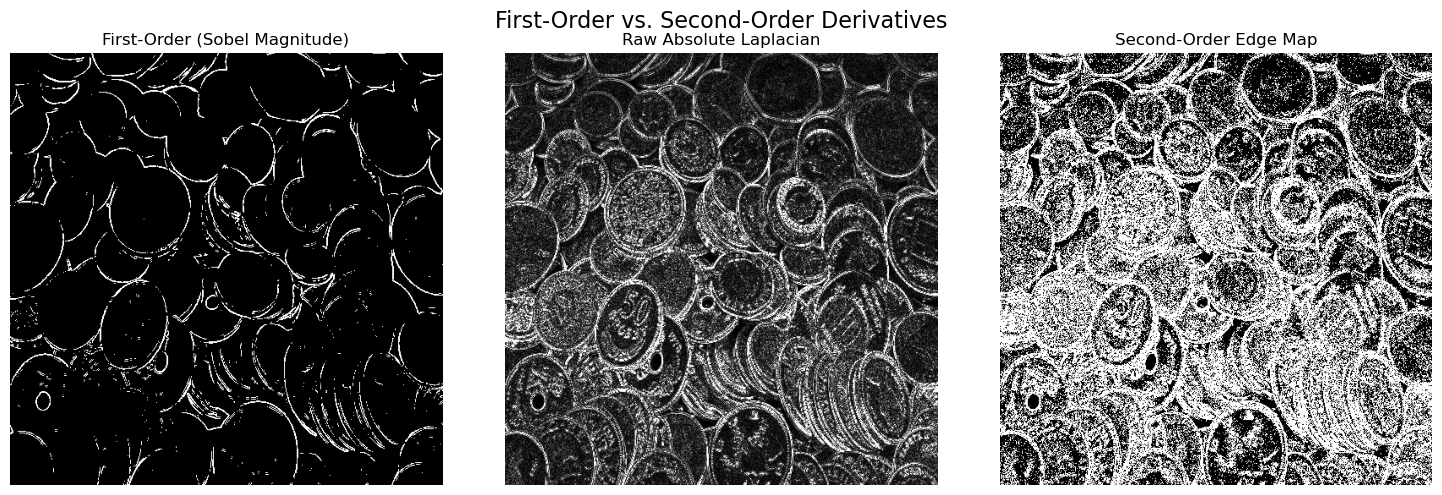

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("First-Order vs. Second-Order Derivatives", fontsize=16)

# Display First-Order (Medium Threshold from Part 2) for comparison
axes[0].imshow(edge_med, cmap='gray')
axes[0].set_title("First-Order (Sobel Magnitude)")
axes[0].axis('off')

# Display Raw Absolute Laplacian
axes[1].imshow(lap_abs, cmap='gray', vmax=255) # Cap display brightness
axes[1].set_title("Raw Absolute Laplacian")
axes[1].axis('off')

# Display Binary Laplacian Edge Map
axes[2].imshow(lap_binary, cmap='gray')
axes[2].set_title("Second-Order Edge Map")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [14]:
def generate_log_and_canny(img, canny_t1=100, canny_t2=200):
    # 1. Laplacian of Gaussian (LoG)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    # Reusing our scratch function to obey the strict rule!
    log_raw = compute_laplacian_scratch(blurred) 
    log_abs = np.abs(log_raw)
    
    # Threshold LoG to make it binary
    log_binary = np.zeros_like(log_abs, dtype=np.uint8)
    log_binary[log_abs >= 30] = 255
    
    # 2. Canny Edge Detector (Built-in is allowed for this specific task)
    canny_edges = cv2.Canny(img, canny_t1, canny_t2)
    
    return log_binary, canny_edges

In [16]:
log_b, canny_b = generate_log_and_canny(img_boundaries, 100, 200)

# Process Image 2: Fine Details (Mandrill)
log_d, canny_d = generate_log_and_canny(img_details, 50, 120)


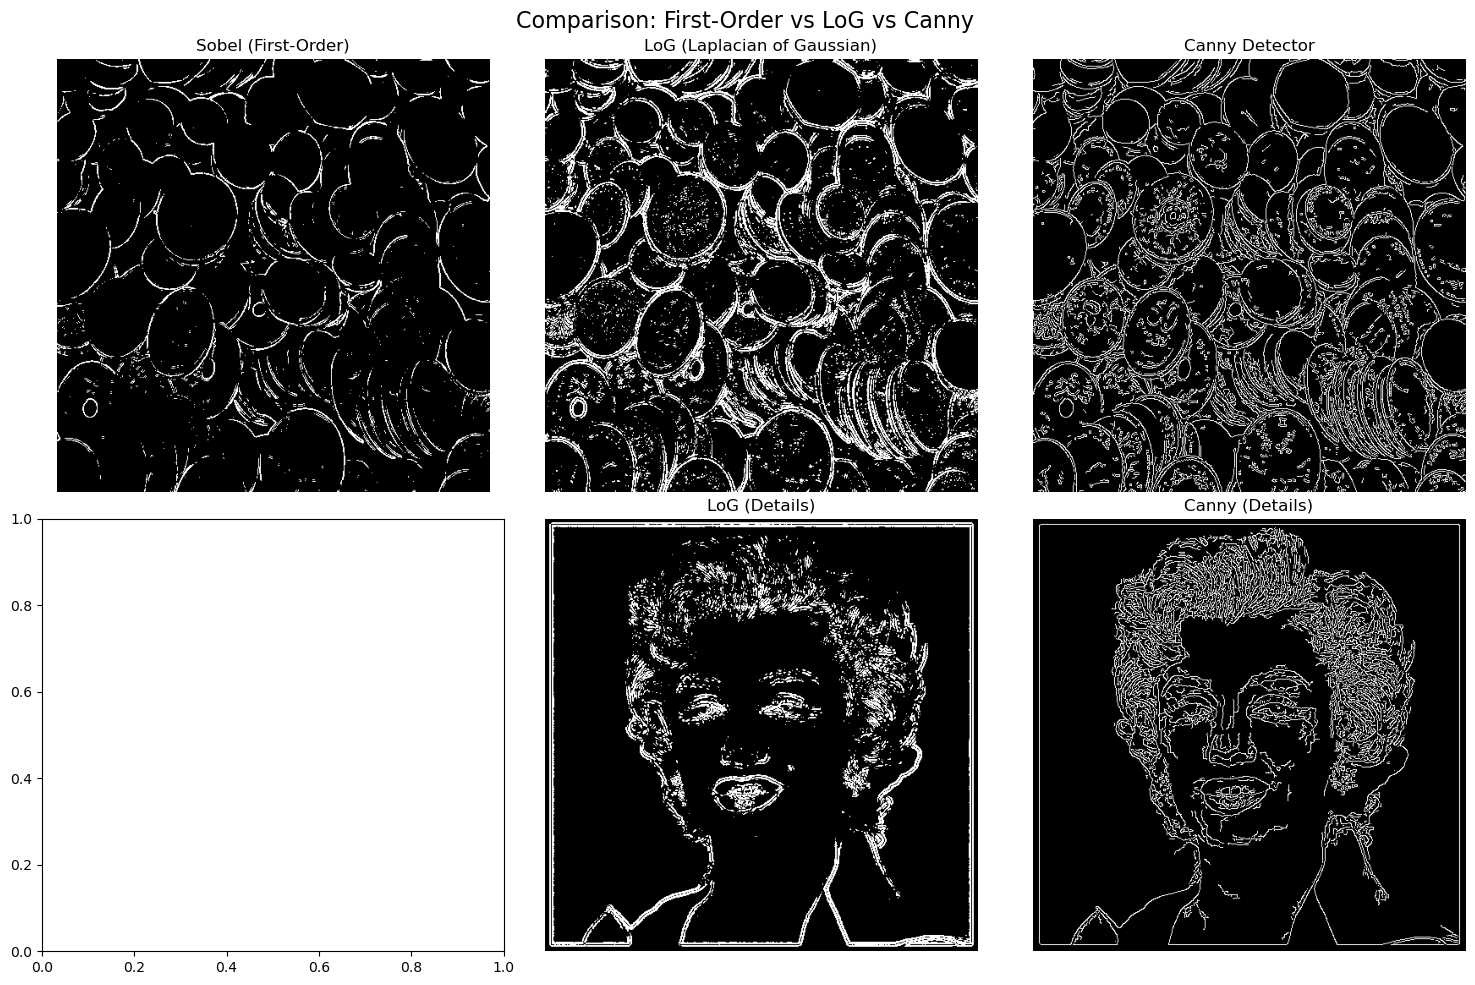

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Comparison: First-Order vs LoG vs Canny", fontsize=16)

# Row 1: Clear Boundaries Image
axes[0, 0].imshow(edge_med, cmap='gray') # From Part 2
axes[0, 0].set_title("Sobel (First-Order)")
axes[0, 0].axis('off')

axes[0, 1].imshow(log_b, cmap='gray')
axes[0, 1].set_title("LoG (Laplacian of Gaussian)")
axes[0, 1].axis('off')

axes[0, 2].imshow(canny_b, cmap='gray')
axes[0, 2].set_title("Canny Detector")
axes[0, 2].axis('off')

# Row 2: Fine Details Image
# (Assuming you ran Part 1 & 2 on img_details to get edge_med_d)
# If not, replace edge_med_d with img_details for reference
axes[1, 1].imshow(log_d, cmap='gray')
axes[1, 1].set_title("LoG (Details)")
axes[1, 1].axis('off')

axes[1, 2].imshow(canny_d, cmap='gray')
axes[1, 2].set_title("Canny (Details)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()